# Burgers Equation — LF Scheme $\alpha$ Optimisation (PyTorch)

## Framework
| Component | Choice |
|-----------|--------|
| Parameter | `nn.Parameter` — unconstrained, allows $\alpha\in(-\infty,+\infty)$ |
| Optimiser | Adam warm-up → L-BFGS refinement |
| Loss | MSE + $\lambda_\text{tv}$ TVD penalty |
| Part 1 | scalar $\alpha$ (1 parameter) |
| Part 2 | space-time $\alpha_i(t)$ ($N$ parameters per step) |

## LF scheme
$$u_i^{n+1}=u_i^n-\frac{\Delta t}{2\Delta x}(f_{i+1}-f_{i-1})+\frac{\alpha\,\Delta t}{2\Delta x}(u_{i+1}-2u_i+u_{i-1}),\quad f=u^2/2$$

Standard LF: $\alpha=\Delta x/\Delta t=1.25$. Negative $\alpha$ = anti-diffusion (sharpening).

## Combined loss
$$\mathcal{L}=\underbrace{\frac{1}{N}\sum_i(u_i^{n+1}-u_i^\text{exact})^2}_{\mathcal{L}_\text{mse}}+\lambda_\text{tv}\,\underbrace{\max\!\left(0,\,\mathrm{TV}(u^{n+1})-\mathrm{TV}(u^n)\right)}_{\mathcal{L}_\text{tvd}}$$

TVD penalty fires only when total variation increases, pushing $\alpha$ toward entropy stability.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# Grid (cell-centred FVM)
L, N = 1.0, 200
dx   = L / N
x_np = np.linspace(dx/2, L - dx/2, N)

# Riemann IC: shock at x0, u_L > u_R
u_L, u_R, x0 = 1.0, 0.0, 0.25
u_init = torch.from_numpy(np.where(x_np <= x0, u_L, u_R).astype(float))

# Time
CFL       = 0.8
dt        = CFL * dx / u_L          # = 0.004
T_final   = 0.40
n_steps   = int(T_final / dt)       # = 100
alpha_std = dx / dt                 # standard LF = 1.25
s         = (u_L + u_R) / 2        # shock speed = 0.5

def exact(t):
    return torch.from_numpy(np.where(x_np < x0 + s*t, u_L, u_R).astype(float))

# Unconstrained parameterisation: raw IS alpha (no sigmoid).
# Positive alpha -> diffusion (stabilising).
# Negative alpha -> anti-diffusion (sharpening); TVD loss penalises overshoot.

def raw2alpha(raw):
    return raw                            # identity — alpha in (-inf, +inf)

def alpha2raw(a):
    return torch.tensor(float(a))         # identity inverse

# Standard LF baseline (numpy)
def lf_np(u, alpha):
    u_p=np.roll(u,-1); u_m=np.roll(u,1)
    f=0.5*u**2; f_p=np.roll(f,-1); f_m=np.roll(f,1)
    u_new = u-(dt/(2*dx))*(f_p-f_m)+(alpha*dt/(2*dx))*(u_p-2*u+u_m)
    u_new[0]=u_L; u_new[-1]=u_R; return u_new

u_std = u_init.numpy().copy()
for _ in range(n_steps):
    u_std = lf_np(u_std, alpha_std)

print(f"dx={dx:.4f}  dt={dt:.5f}  alpha_std={alpha_std:.4f}  n_steps={n_steps}")
print(f"Shock at T={T_final}: x_shock = {x0 + s*T_final:.3f}")
print(f"MSE standard LF: {np.mean((u_std - exact(T_final).numpy())**2):.4e}")


dx=0.0050  dt=0.00400  alpha_std=1.2500  n_steps=100
Shock at T=0.4: x_shock = 0.450
MSE standard LF: 1.6849e-03


In [2]:
# PyTorch LF update (differentiable w.r.t. alpha)
def lf_torch(u, alpha):
    u_p = torch.roll(u, -1); u_m = torch.roll(u, 1)
    f   = 0.5 * u**2
    f_p = torch.roll(f, -1); f_m = torch.roll(f, 1)
    lap = u_p - 2*u + u_m
    u_new = u - (dt/(2*dx))*(f_p - f_m) + (alpha * dt/(2*dx)) * lap
    # Dirichlet BCs: replace boundary cells with constants (no grad)
    u_bc = torch.cat([u_new.new_full((1,), u_L), u_new[1:-1], u_new.new_full((1,), u_R)])
    return u_bc

def total_var(u):
    return torch.sum(torch.abs(u[1:] - u[:-1]))

def step_loss(u_old, alpha, u_ex, lam_tv=0.01):
    u_new = lf_torch(u_old, alpha)
    mse   = torch.mean((u_new - u_ex)**2)
    tvd   = F.relu(total_var(u_new) - total_var(u_old))
    return mse + lam_tv * tvd, u_new

print("lf_torch, total_var, step_loss defined.")


lf_torch, total_var, step_loss defined.


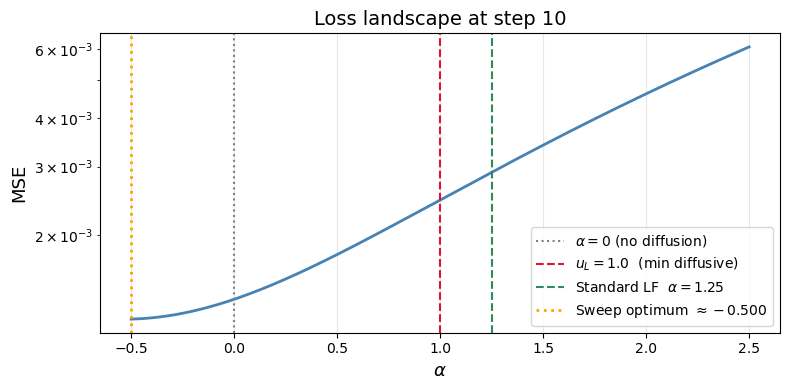

Sweep optimal alpha: -0.5000


In [3]:
# Loss landscape: sweep alpha at step 10 (numpy, for speed)
n_demo = 10
u_demo = u_init.numpy().copy()
for _ in range(n_demo): u_demo = lf_np(u_demo, alpha_std)
u_ex_demo = exact((n_demo + 1) * dt).numpy()

alphas_sw = np.linspace(-0.5, 2.5, 350)
mse_sw    = [np.mean((lf_np(u_demo, a) - u_ex_demo)**2) for a in alphas_sw]
opt_a     = alphas_sw[np.argmin(mse_sw)]

plt.figure(figsize=(8, 4))
plt.plot(alphas_sw, mse_sw, 'steelblue', lw=2)
plt.axvline(0,         color='gray',     ls=':',  lw=1.5, label='$\\alpha=0$ (no diffusion)')
plt.axvline(u_L,       color='crimson',  ls='--', lw=1.5, label=f'$u_L={u_L}$  (min diffusive)')
plt.axvline(alpha_std, color='seagreen', ls='--', lw=1.5, label=f'Standard LF  $\\alpha={alpha_std:.2f}$')
plt.axvline(opt_a,     color='orange',   ls=':',  lw=2,   label=f'Sweep optimum $\\approx{opt_a:.3f}$')
plt.xlabel(r'$\alpha$', fontsize=13); plt.ylabel('MSE', fontsize=13)
plt.title('Loss landscape at step 10', fontsize=14)
plt.yscale('log'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"Sweep optimal alpha: {opt_a:.4f}")


 Step |    alpha |          MSE |    TVD pen
--------------------------------------------------
   25 |  0.83060 |   1.2836e-03 | 0.0000e+00
   50 |  0.88789 |   1.3210e-03 | 1.5425e-12
   75 |  0.88811 |   1.3217e-03 | 1.5445e-12
  100 |  0.88812 |   1.3217e-03 | 0.0000e+00


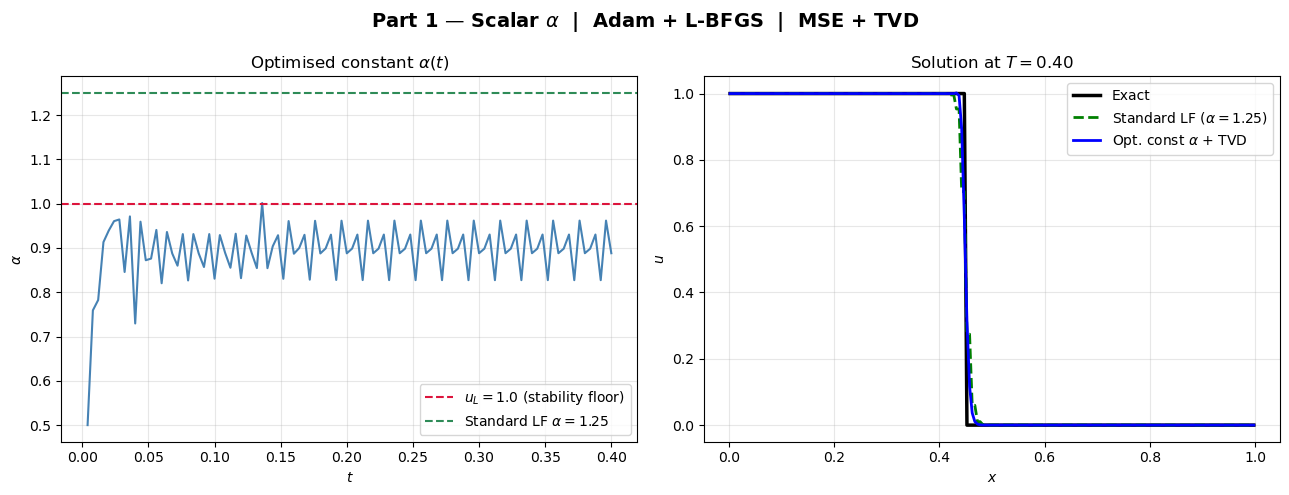


MSE opt const alpha: 1.3217e-03
MSE standard LF:     1.6849e-03


In [4]:
# =====================================================================
# Part 1 — Scalar alpha  |  nn.Parameter  |  Adam -> L-BFGS  |  MSE+TVD
# =====================================================================
N_ADAM  = 80;  LR_ADAM  = 0.3
N_LBFGS = 10;  LR_LBFGS = 0.2
LAM_TV  = 0.01

u_c      = u_init.clone()
raw_c    = nn.Parameter(alpha2raw(alpha_std).reshape(1))   # shape (1,)
alpha_log_c = []; mse_log_c = []

print(f"{'Step':>5} | {'alpha':>8} | {'MSE':>12} | {'TVD pen':>10}")
print("-" * 50)

for n in range(1, n_steps + 1):
    t     = n * dt
    u_ex  = exact(t)
    u_old = u_c.detach()

    raw = nn.Parameter(raw_c.detach().clone())

    # Adam warm-up
    opt_adam = torch.optim.Adam([raw], lr=LR_ADAM)
    for _ in range(N_ADAM):
        opt_adam.zero_grad()
        loss, _ = step_loss(u_old, raw2alpha(raw), u_ex, LAM_TV)
        loss.backward()
        opt_adam.step()

    # L-BFGS refinement
    opt_lbfgs = torch.optim.LBFGS([raw], lr=LR_LBFGS, max_iter=10,
                                    history_size=10, tolerance_grad=1e-5,
                                    line_search_fn='strong_wolfe')
    def closure_c():
        opt_lbfgs.zero_grad()
        loss, _ = step_loss(u_old, raw2alpha(raw), u_ex, LAM_TV)
        loss.backward()
        return loss

    for _ in range(N_LBFGS):
        opt_lbfgs.step(closure_c)

    # Advance
    with torch.no_grad():
        alpha_opt = raw2alpha(raw).item()
        u_c       = lf_torch(u_old, alpha_opt).detach()
        raw_c     = raw.detach()

    mse_v = torch.mean((u_c - u_ex)**2).item()
    tvd_v = F.relu(total_var(u_c) - total_var(u_old)).item()
    alpha_log_c.append(alpha_opt)
    mse_log_c.append(mse_v)

    if n % 25 == 0:
        print(f"{n:>5} | {alpha_opt:>8.5f} | {mse_v:>12.4e} | {tvd_v:>10.4e}")

# Plots
u_ex_f = exact(T_final)
t_arr  = np.arange(1, n_steps + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_arr, alpha_log_c, 'steelblue', lw=1.5)
axes[0].axhline(u_L,       color='crimson',  ls='--', label=f'$u_L={u_L}$ (stability floor)')
axes[0].axhline(alpha_std, color='seagreen', ls='--', label=f'Standard LF $\\alpha={alpha_std:.2f}$')
axes[0].set_xlabel('$t$'); axes[0].set_ylabel(r'$\alpha$')
axes[0].set_title('Optimised constant $\\alpha(t)$'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_np, u_ex_f.numpy(), 'k-',  lw=2.5, label='Exact')
axes[1].plot(x_np, u_std,          'g--', lw=2,   label=f'Standard LF ($\\alpha={alpha_std:.2f}$)')
axes[1].plot(x_np, u_c.numpy(),    'b-',  lw=2,   label='Opt. const $\\alpha$ + TVD')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$u$')
axes[1].set_title(f'Solution at $T={T_final:.2f}$'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Part 1 — Scalar $\\alpha$  |  Adam + L-BFGS  |  MSE + TVD',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

mse_c = np.mean((u_c.numpy() - u_ex_f.numpy())**2)
print(f"\nMSE opt const alpha: {mse_c:.4e}")
print(f"MSE standard LF:     {np.mean((u_std - u_ex_f.numpy())**2):.4e}")


 Step | mean alpha |          MSE
--------------------------------------
   25 |    1.21381 |   5.4641e-08
   50 |    1.18646 |   3.5158e-08
   75 |    1.18198 |   3.2703e-08
  100 |    1.13918 |   5.8565e-08


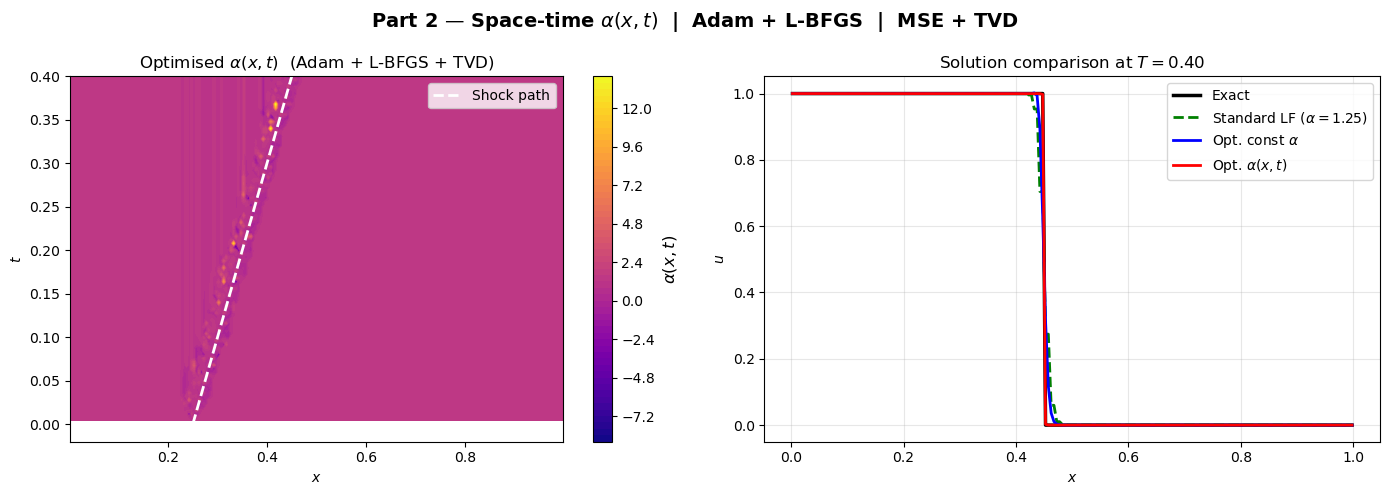


MSE opt space-time alpha: 5.8565e-08
MSE opt const alpha:      1.3217e-03
MSE standard LF:          1.6849e-03


In [5]:
# =====================================================================
# Part 2 — Space-time alpha_i(t)  |  N nn.Parameters  |  Adam -> L-BFGS
# =====================================================================
# Space-time needs more epochs: 200 params vs 1 param for scalar.
# Laplacian is non-zero in only ~5/200 cells (shock region),
# so most alpha_i see near-zero gradient -> slow convergence.
N_ADAM_S  = 300;  LR_ADAM_S  = 0.3
N_LBFGS_S = 15;   LR_LBFGS_S = 0.2

u_s      = u_init.clone()
raw_s    = nn.Parameter(torch.full((N,), alpha2raw(alpha_std).item()))
alpha_st = []   # list of (N,) arrays, one per step
t_st     = []

print(f"{'Step':>5} | {'mean alpha':>10} | {'MSE':>12}")
print("-" * 38)

for n in range(1, n_steps + 1):
    t     = n * dt
    u_ex  = exact(t)
    u_old = u_s.detach()

    raw = nn.Parameter(raw_s.detach().clone())

    # Adam warm-up
    opt_adam = torch.optim.Adam([raw], lr=LR_ADAM_S)
    for _ in range(N_ADAM_S):
        opt_adam.zero_grad()
        loss, _ = step_loss(u_old, raw2alpha(raw), u_ex, LAM_TV)
        loss.backward()
        opt_adam.step()

    # L-BFGS refinement
    opt_lbfgs = torch.optim.LBFGS([raw], lr=LR_LBFGS_S, max_iter=10,
                                    history_size=10, tolerance_grad=1e-5,
                                    line_search_fn='strong_wolfe')
    def closure_s():
        opt_lbfgs.zero_grad()
        loss, _ = step_loss(u_old, raw2alpha(raw), u_ex, LAM_TV)
        loss.backward()
        return loss

    for _ in range(N_LBFGS_S):
        opt_lbfgs.step(closure_s)

    # Advance
    with torch.no_grad():
        alpha_opt = raw2alpha(raw).detach()
        u_s       = lf_torch(u_old, alpha_opt).detach()
        raw_s     = raw.detach()

    alpha_st.append(alpha_opt.numpy().copy())
    t_st.append(t)

    if n % 25 == 0:
        mse_v = torch.mean((u_s - u_ex)**2).item()
        print(f"{n:>5} | {alpha_opt.mean().item():>10.5f} | {mse_v:>12.4e}")

alpha_st_arr = np.array(alpha_st)   # (n_steps, N)

# Contour: alpha(x, t)
T_g, X_g = np.meshgrid(t_st, x_np)
u_ex_f    = exact(T_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cp = axes[0].contourf(X_g, T_g, alpha_st_arr.T, levels=60, cmap='plasma')
plt.colorbar(cp, ax=axes[0]).set_label(r'$\alpha(x,t)$', fontsize=12)
t_ln = np.array([0, T_final])
axes[0].plot(x0 + s*t_ln, t_ln, 'w--', lw=2, label='Shock path')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$t$')
axes[0].set_title(r'Optimised $\alpha(x,t)$  (Adam + L-BFGS + TVD)')
axes[0].legend()

axes[1].plot(x_np, u_ex_f.numpy(), 'k-',  lw=2.5, label='Exact')
axes[1].plot(x_np, u_std,          'g--', lw=2,   label=f'Standard LF ($\\alpha={alpha_std:.2f}$)')
axes[1].plot(x_np, u_c.numpy(),    'b-',  lw=2,   label='Opt. const $\\alpha$')
axes[1].plot(x_np, u_s.numpy(),    'r-',  lw=2,   label=r'Opt. $\alpha(x,t)$')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$u$')
axes[1].set_title(f'Solution comparison at $T={T_final:.2f}$')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(r'Part 2 — Space-time $\alpha(x,t)$  |  Adam + L-BFGS  |  MSE + TVD',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

mse_s = np.mean((u_s.numpy() - u_ex_f.numpy())**2)
print(f"\nMSE opt space-time alpha: {mse_s:.4e}")
print(f"MSE opt const alpha:      {mse_c:.4e}")
print(f"MSE standard LF:          {np.mean((u_std - u_ex_f.numpy())**2):.4e}")
